### Scikit Learn Documentation
https://scikit-learn.org/1.6/index.html

### 1. Preprocessor

In [1]:
# -------------------------------------
# Standard libraries
# -------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------
# Scikit-learn
# -------------------------------------
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, root_mean_squared_error, r2_score
from sklearn import set_config
# -------------------------------------
# Config
# -------------------------------------
set_config(transform_output='pandas')

# -------------------------------------
# Reading Data
# -------------------------------------
url = 'https://drive.google.com/file/d/11uf0ZqHzD0dgcNoO3_z2ejDtJxr7pq_G/view?usp=sharing'
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]
data = pd.read_csv(path)

# -------------------------------------
# Feature (X) and Target Separation (y)
# -------------------------------------
X = data.copy()
y = X.pop('SalePrice')

# -------------------------------------
# Train-Test Split
# -------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=3146)

# -------------------------------------
# Train Data for Plotting
# -------------------------------------
train_data = X_train.copy()
train_data['SalePrice'] = y_train

### Ordinal / Nominal / Binary Columns & ColumnTransformer + Pipelines

In [2]:
# -------------
# Column Groups
# -------------

ordinal_num = ['OverallQual', 'OverallCond']
nominal_num = ['MSSubClass']
num_features = [col for col in X.select_dtypes(include='number').columns if col not in ordinal_num + nominal_num]

ordinal_cat = {
    'LotShape':['IR3', 'IR2', 'IR1', 'Reg'],
    'LandContour':['Low', 'HLS', 'Bnk', 'Lvl'],
    'Utilities':['ELO', 'NoSeWa', 'NoSewr', 'AllPub'],
    'LandSlope':['Sev','Mod','Gtl'],
    'ExterQual':['Po','Fa','TA','Gd','Ex'],
    'ExterCond':['Po','Fa','TA','Gd','Ex'],
    'BsmtQual':['N_A','Po','Fa','TA','Gd','Ex'],
    'BsmtCond':['N_A','Po','Fa','TA','Gd','Ex'],
    'BsmtExposure':['N_A','No','Mn','Av','Gd'],
    'BsmtFinType1':['N_A','Unf','LwQ','Rec','BLQ','ALQ','GLQ'],
    'BsmtFinType2':['N_A','Unf','LwQ','Rec','BLQ','ALQ','GLQ'],
    'HeatingQC':['Po','Fa','TA','Gd','Ex'],
    'Electrical':['N_A','Mix','FuseP','FuseF','FuseA','SBrkr'],
    'KitchenQual':['Po','Fa','TA','Gd','Ex'],
    'Functional':['Sal','Sev','Maj2','Maj1','Mod','Min2','Min1','Typ'],
    'FireplaceQu':['N_A','Po','Fa','TA','Gd','Ex'],
    'GarageFinish':['N_A','Unf','RFn','Fin'],
    'GarageQual':['N_A','Po','Fa','TA','Gd','Ex'],
    'GarageCond':['N_A','Po','Fa','TA','Gd','Ex'],
    'PavedDrive':['N','P','Y'],
    'PoolQC':['N_A','Fa','TA','Gd','Ex'],
    'Fence': ['N_A', 'MnWw', 'MnPrv', 'GdWo', 'GdPrv']
    }

binary_cols = ['CentralAir','Street']

nominal_cat = [col for col in X.select_dtypes(exclude='number').columns if col not in list(ordinal_cat.keys()) + binary_cols]


# ------------------------------------------------
# Preprocessor (Pipelines + ColumnTransformer!)
# ------------------------------------------------

preprocessor = ColumnTransformer(transformers=[
    # Plain numerical: impute with mean, then scale
    ('num', make_pipeline(
        SimpleImputer(strategy='mean'),
        StandardScaler()
    ), num_features),

    # Ordinal numerical
    ('ordinal_num', make_pipeline(
        SimpleImputer(strategy='mean'),
        StandardScaler()
    ), ordinal_num),

    # Nominal numerical: impute, then one-hot encode
    ('nominal_num', make_pipeline(
        SimpleImputer(strategy='most_frequent'),
        OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    ), nominal_num),

    # Ordinal Categorical: impute with N_A, then ordinal encode
    ('ordinal_cat', make_pipeline(
        SimpleImputer(strategy='constant', fill_value='N_A'),
        OrdinalEncoder(categories=list(ordinal_cat.values()))
    ), list(ordinal_cat.keys())),

    # Binary categorical: impute, then ordinal encode as 0/1
    ('binary', make_pipeline(
        SimpleImputer(strategy='most_frequent'),
        OrdinalEncoder()
    ), binary_cols),

    # Nominal categorical: impute with N_A, then one-hot encode
    ('nominal_cat', make_pipeline(
        SimpleImputer(strategy='constant', fill_value='N_A'),
        OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    ), nominal_cat),
])

preprocessor


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer()),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 ['Id', 'LotFrontage', 'LotArea', 'YearBuilt',
                                  'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
                                  'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
                                  '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
                                  'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath',
                                  'FullBath', 'HalfBath',...
                                                  SimpleImputer(fill_value='N_A',
                                                                strategy='constant')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['MSZoning', 'Alley', 'LotConfig',
                                  'Neighborhood', 'Condition1', 'Condition2',
                                  'BldgType', 'HouseStyle', 'RoofStyle',
                                  'RoofMatl', 'Exterior1st', 'Exterior2nd',
                                  'MasVnrType', 'Foundation', 'Heating',
                                  'GarageType', 'MiscFeature', 'SaleType',
                                  'SaleCondition'])])

### Creating a Baseline Model

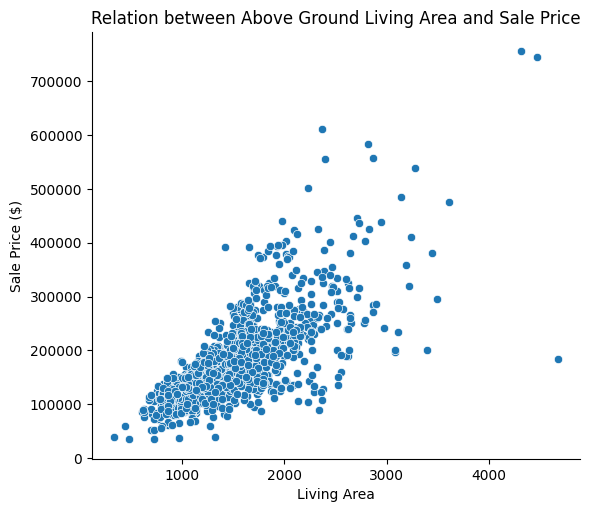

In [3]:
(
    sns.relplot(data=train_data,
                x='GrLivArea',
                y='SalePrice',
                height=5,
                aspect=1.2)
    .set(title='Relation between Above Ground Living Area and Sale Price')
    .set_axis_labels('Living Area', 'Sale Price ($)')
);

In [4]:
# Makes SalePrice predictions based on GrLivArea alone to set a baseline.
# Parameters:
# X: df of predictor features
# Returns:
# price_pred: series of price predictions

def baseline_model(X):
  # multiplier outcome = $ per square foot
    multiplier = y_train.mean() / X_train['GrLivArea'].mean()
    price_pred = X['GrLivArea'] * multiplier
    return round(price_pred, 2)

In [5]:
baseline_test_pred = baseline_model(X_test)
# baseline_test_pred

### Assessing Regression Models

In [6]:
# Mean Absolute Error (MAE)

baseline_mae = mean_absolute_error(
    y_true = y_test,
    y_pred = baseline_test_pred
)
baseline_mae

38908.261780821915

In [7]:
# Root Mean Squared Error (RMSE)

baseline_rmse = root_mean_squared_error(
    y_true = y_test,
    y_pred = baseline_test_pred
)
baseline_rmse

59678.01284857313

In [8]:
# Mean Absolute Percentage Error

baseline_mape = mean_absolute_percentage_error(
    y_true= y_test,
    y_pred = baseline_test_pred
)
baseline_mape

0.23592736200429254

In [9]:
# R-Squared

baseline_r2 = r2_score(
    y_true = y_test,
    y_pred= baseline_test_pred
)
baseline_r2

0.4319849336256498

Creating a function to compare scores as well as an empty DF to save the outputs

In [10]:
# Function to get the scores for our model(s)
def score_model(model, y_true, y_pred):
  scores = {
      'Model': model,
      'MAE ($)': round(mean_absolute_error(y_true, y_pred), 2),
      'RMSE ($)': round(root_mean_squared_error(y_true, y_pred), 2),
      'MAPE (%)': round(100 * mean_absolute_percentage_error(y_true, y_pred), 2),
      'R-Squared': round(r2_score(y_true, y_pred), 3)
  }
  return scores

# setting up an empty list for score comparison
model_scores = []

# converting into DF
model_scores.append(score_model('Baseline Model', y_test, baseline_test_pred))
pd.DataFrame(model_scores)

,Model,MAE ($),RMSE ($),MAPE (%),R-Squared
0,Baseline Model,38908.26,59678.01,23.59,0.432


### Training Models

DecisionTreeRegressor

In [11]:
# Creating a pipeline with DT Regressor
dt_pipeline = make_pipeline(
    preprocessor,
    DecisionTreeRegressor(random_state=42)
)
dt_pipeline.fit(X_train, y_train)

# Predicting with DecisionTreeRegressor
dt_predictions = dt_pipeline.predict(X_test)

Adding the scores to the DF

In [12]:
model_scores.append(score_model('Decision Tree', y_test, dt_predictions))
pd.DataFrame(model_scores)

,Model,MAE ($),RMSE ($),MAPE (%),R-Squared
0,Baseline Model,38908.26,59678.01,23.59,0.432
1,Decision Tree,27187.00,40228.08,15.35,0.742


SGDRegressor

In [13]:
sgd_pipeline = make_pipeline(
    preprocessor,
    SGDRegressor(random_state=42)
)

sgd_pipeline.fit(X_train, y_train)

sgd_predictions = sgd_pipeline.predict(X_test)

In [14]:
model_scores.append(score_model('Stochastic Gradient Descent', y_test, sgd_predictions))
pd.DataFrame(model_scores)

,Model,MAE ($),RMSE ($),MAPE (%),R-Squared
0,Baseline Model,38908.26,59678.01,23.59,0.432
1,Decision Tree,27187.00,40228.08,15.35,0.742
2,Stochastic Gradient Descent,19912.81,44510.49,12.19,0.684


LinearRegression

In [15]:
lr_pipeline = make_pipeline(
    preprocessor,
    LinearRegression()
)

lr_pipeline.fit(X_train, y_train)

lr_predictions = lr_pipeline.predict(X_test)

In [16]:
model_scores.append(score_model('Linear Regression', y_test, lr_predictions))
pd.DataFrame(model_scores)

,Model,MAE ($),RMSE ($),MAPE (%),R-Squared
0,Baseline Model,38908.26,59678.01,23.59,0.432
1,Decision Tree,27187.00,40228.08,15.35,0.742
2,Stochastic Gradient Descent,19912.81,44510.49,12.19,0.684
3,Linear Regression,21536.48,47647.37,13.01,0.638


### Comparing Models

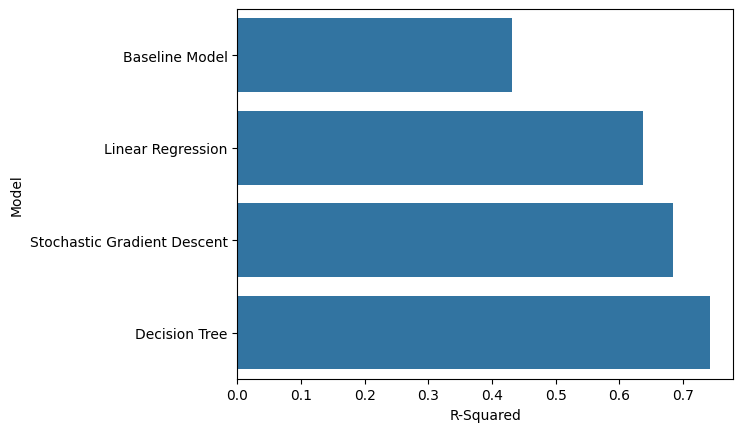

In [17]:
model_scores_df = pd.DataFrame(model_scores)

sns.barplot(
    data = model_scores_df.sort_values(by='R-Squared'),
    y='Model',
    x='R-Squared'
);